# 情绪生成器图
目标：根据条件边的返回，走不同的路径


## 有什么新内容：
- 状态类型：TypedDict
- 在nodes中访问自定义的状态
- 通过node的返回值更新自定义状态
- 枚举类型：Literal
- random模块的random函数，用户产生随机数


## 实现思路：

1. 通用前置步骤：创建llm_client
2. 创建图：
    -  定义State
    -  定义node
    -  创建graph
    -  在graph中添加node
    -  在graph中的node之间添加edge
3. 编译图，即校验图的合法性并添加运行时（这个运行时暂时不知道干了啥，只知道可以invoke）
4. 可视化图结构，检查编排流程
5. 调用图


In [24]:
# 通用步骤
from langchain_openai import ChatOpenAI


glm_client = ChatOpenAI(
    api_key="d1de7475090740ebb6c887167a6a8b98.2WUSfYbmgQwYLKF4",
    base_url="https://open.bigmodel.cn/api/paas/v4/",
    model="glm-4.7",
)

In [25]:
# 创建图
from random import random
from typing import Literal, TypedDict

from langgraph.graph import START, StateGraph


# 定义State
class State(TypedDict):
    graph_state:str

# 定义节点
def node_1(state:State)->State:
    print("node_1")
    return {"graph_state":state["graph_state"] + "i am "}

def node_2(state:State)->State:
    print("node sad")
    return {"graph_state":state["graph_state"] + "sad"}

def node_3(state:State) ->State:
    print("node happy")
    return {"graph_state":state["graph_state"] + 'happy'}

def decide_mood(state:State)-> Literal['node_sad','node_happy']:
    if random() > 0.5:
        return 'node_sad'
    else:
        return 'node_happy'

# 实例化图
graph = StateGraph(State)
graph.add_node('node_1',node_1)
graph.add_node("node_sad", node_2)
graph.add_node("node_happy",node_3)

graph.add_edge(START, "node_1")
graph.add_conditional_edges("node_1", decide_mood, ["node_sad", "node_happy"])

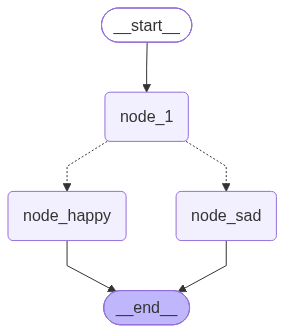

In [26]:
# 编译图并打印其结构

from IPython.display import display, Image


app  = graph.compile()
display(Image(app.get_graph().draw_mermaid_png()))

In [27]:
# 运行图
app.invoke({'graph_state':'hi, this is ryan.'})

node_1
node happy


{'graph_state': 'hi, this is ryan.i am happy'}